In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, FunctionTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df=pd.read_csv("development.csv")

In [3]:
df.shape

(5546, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5546 entries, 0 to 5545
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   catcher_id                 5546 non-null   int64  
 1   jobma_catcher_status       5546 non-null   int64  
 2   jobma_catcher_type         5546 non-null   int64  
 3   subscription_status        5546 non-null   int64  
 4   subscription_type          5546 non-null   int64  
 5   referral_credit            5546 non-null   int64  
 6   is_premium                 5546 non-null   int64  
 7   sub_user                   5546 non-null   int64  
 8   company_size               5546 non-null   object 
 9   per_sub_user               5546 non-null   float64
 10  number_of_logins           5546 non-null   float64
 11  jobma_login_status         5546 non-null   float64
 12  days_since_login           5546 non-null   float64
 13  wallet_sum                 5546 non-null   float

In [5]:
# Fill missing values in the DataFrame
def fill_missing_values(df):
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0).astype(int)
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

df = fill_missing_values(df)

In [6]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'subscription_status',
                  'jobma_login_status',
                  'subscription_type',
                  'referral_credit',
                  'is_unlimited',
                  'is_premium',
                  'plan_type',
                  'currency'
                 ]

categorical_columns = ['company_size']
                   
ordinal_columns = ['sub_user',
                    'catcher_id',
                    'wallet_sum',
                    'per_sub_user',
                    'number_of_logins',
                    'days_since_login',
                    'subscription_sum',
                    'subscription_count',
                    'premium_plan_id',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'number_of_invitations',
                    'number_of_pitcher_applied',
                    'pre_rec_interviews_counts',
                    'live_interviews_counts',
                    'ai_kit_counts',
                    'ai_interviews_counts'
                   ]

In [7]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)


def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

# Clean ordinal values
def clean_ordinal(X):
    return X.clip(lower=0)

In [8]:
#Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('scaler', StandardScaler())
                                 ])

#Categorical pipeline
categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                       ('scaler', StandardScaler())
                                      ])

#Ordinal pipeline
ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(log_transform, validate=False)),
                                   ('scaler', StandardScaler())
                                  ])

#Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               # ('id', 'passthrough', ['catcher_id']),
                                               #('scaler', StandardScaler())
                                              ])

#pipeline
pipeline = Pipeline([('preprocessing', preprocessor)])

In [9]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x00000252078730A0>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['jobma_catcher_status',
                                                   'jobma_catcher_type',
                                                   'subscription_status',
                                                   'jobma_login_status',
                                                   'subscripti...
                                                                   StandardScaler())]),
                                                  ['sub_user', 'catcher_id',
                                                   'wallet_sum', 'per_sub_user',
                                                   'number_of_logins',
                                                   'days_since_login',
                                                   'subscription_sum',
                                                   'subscription_count',
                                                   'premium_plan_id',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'number_of_invitations',
                                                   'number_of_pitcher_applied',
                                                   'pre_rec_interviews_counts',
                                                   'live_interviews_counts',
                                                   'ai_kit_counts',
                                                   'ai_interviews_counts'])]))])

In [10]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([5546, 32])

# #Autoencoder and decoder model for word emedding

In [11]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

# Initialize model and Optimizers

In [12]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 40
batch_size = 16

In [13]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)
    

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 5/40, Loss: 5.8238
Epoch 10/40, Loss: 3.0659
Epoch 15/40, Loss: 2.4321
Epoch 20/40, Loss: 1.6817
Epoch 25/40, Loss: 0.9449
Epoch 30/40, Loss: 0.7409
Epoch 35/40, Loss: 0.3234
Epoch 40/40, Loss: 0.3459


In [14]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(5546, 32)

In [15]:
type(embeddings_np), embeddings.shape

(numpy.ndarray, torch.Size([5546, 32]))

# 2D for visualization, # Plot PCA and tsne

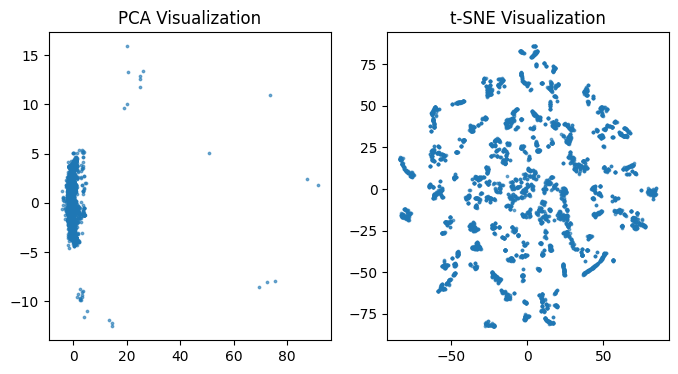

In [16]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()


In [17]:
#Recommend top N candidates based on cosine similarity. #cosine similarity # Sort by similarity
##################################################


def recommend_client(query_index, embedings, top_n=5):
    similarities = cosine_similarity([embeddings[query_index]], embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n + 1]

    print(f"\nTop {top_n} similar clients as index {query_index}:")
    for i, idx in enumerate(top_indices):
        print(f"{i}. Client {idx} - Similarity: {similarities[idx]:.4f}")

recommend_client(841, embeddings_np, top_n=10)


Top 10 similar clients as index 841:
0. Client 841 - Similarity: 1.0000
1. Client 5374 - Similarity: 0.9983
2. Client 5537 - Similarity: 0.9030
3. Client 5370 - Similarity: 0.6901
4. Client 5400 - Similarity: 0.6765
5. Client 3914 - Similarity: 0.6448
6. Client 5539 - Similarity: 0.6178
7. Client 1079 - Similarity: 0.3831
8. Client 1075 - Similarity: 0.3764
9. Client 1074 - Similarity: 0.3734
10. Client 1073 - Similarity: 0.3687


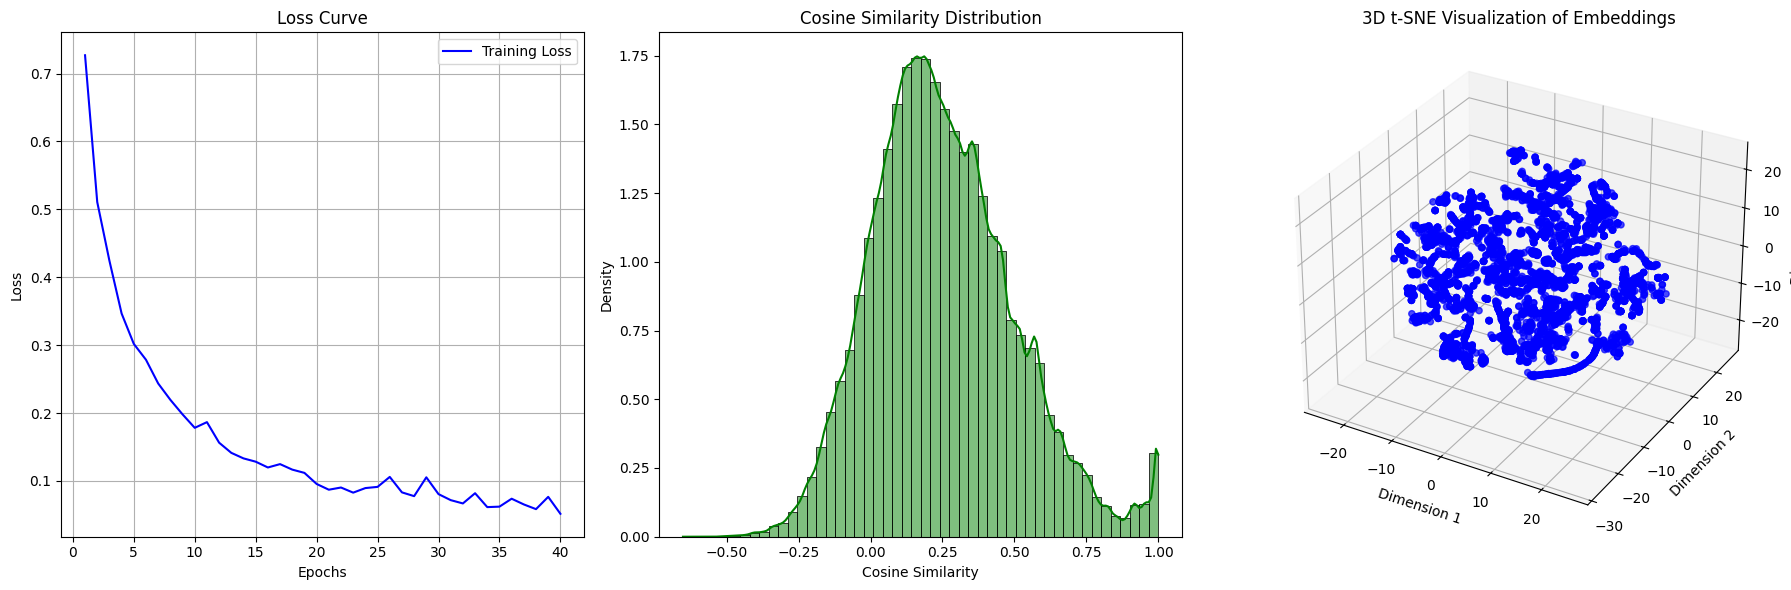

In [19]:
# 1. Create the figure and subplots
fig = plt.figure(figsize=(18, 6))
# --- Loss Curve ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Training Loss', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

# --- Cosine Similarity Distribution ---
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

# --- 3D t-SNE Visualization ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2],
            c='blue', alpha=0.7, s=20)
ax3.set_title('3D t-SNE Visualization of Embeddings')
ax3.set_xlabel('Dimension 1')
ax3.set_ylabel('Dimension 2')
ax3.set_zlabel('Dimension 3')

plt.tight_layout()
plt.show()

In [20]:
df.iloc[355]

catcher_id                    984
jobma_catcher_status            1
jobma_catcher_type              1
subscription_status             2
subscription_type               0
referral_credit                 0
is_premium                      1
sub_user                      999
company_size                 1-25
per_sub_user                  100
number_of_logins                1
jobma_login_status              0
days_since_login             2607
wallet_sum                     30
plan_type                       0
is_unlimited                    0
subscription_sum               99
subscription_count              1
currency                        0
premium_plan_id                 3
pre_recorded_kit_counts         2
number_of_jobs_posted           2
number_of_invitations           8
number_of_pitcher_applied      17
pre_rec_interviews_counts      11
live_interviews_counts          3
ai_kit_counts                   0
ai_interviews_counts            0
Name: 355, dtype: object

In [21]:
df.iloc[720]

catcher_id                   1520
jobma_catcher_status            1
jobma_catcher_type              1
subscription_status             2
subscription_type               0
referral_credit                 0
is_premium                      1
sub_user                      999
company_size                 1-25
per_sub_user                  100
number_of_logins                1
jobma_login_status              0
days_since_login             2305
wallet_sum                    694
plan_type                       0
is_unlimited                    0
subscription_sum               99
subscription_count              1
currency                        0
premium_plan_id                 3
pre_recorded_kit_counts         7
number_of_jobs_posted          31
number_of_invitations          63
number_of_pitcher_applied      80
pre_rec_interviews_counts      61
live_interviews_counts         11
ai_kit_counts                   0
ai_interviews_counts            0
Name: 720, dtype: object

In [22]:
df.iloc[759]

catcher_id                   1637
jobma_catcher_status            1
jobma_catcher_type              1
subscription_status             2
subscription_type               0
referral_credit                 0
is_premium                      1
sub_user                      999
company_size                 1-25
per_sub_user                  100
number_of_logins                1
jobma_login_status              0
days_since_login             2262
wallet_sum                    197
plan_type                       0
is_unlimited                    0
subscription_sum              199
subscription_count              1
currency                        0
premium_plan_id                 3
pre_recorded_kit_counts         2
number_of_jobs_posted          12
number_of_invitations          29
number_of_pitcher_applied       3
pre_rec_interviews_counts       2
live_interviews_counts          1
ai_kit_counts                   0
ai_interviews_counts            0
Name: 759, dtype: object

In [23]:
recommend_client(2, embeddings, top_n=5)


Top 5 similar clients as index 2:
0. Client 2 - Similarity: 1.0000
1. Client 4 - Similarity: 1.0000
2. Client 6 - Similarity: 0.9999
3. Client 7 - Similarity: 0.9999
4. Client 17 - Similarity: 0.9997
5. Client 15 - Similarity: 0.9997


In [24]:
# df

In [25]:
def recommend_from_sample_df(sample_df, full_embeddings, full_df, pipeline, model, top_n=5):
    sample_transformed = pipeline.transform(sample_df)
    if sample_transformed.shape[1] == model.encoder[0].in_features + 1:
        sample_tensor = torch.tensor(sample_transformed[:, :-1], dtype=torch.float32)
    else:
        sample_tensor = torch.tensor(sample_transformed, dtype=torch.float32)

    # Get embeddings
    with torch.no_grad():
        _, sample_embeddings = model(sample_tensor)

    # Compute cosine similarity
    similarities = cosine_similarity(sample_embeddings, full_embeddings)

    for i, sim_row in enumerate(similarities):
        sample_id = sample_df.iloc[i]['catcher_id']
        top_indices = np.argsort(sim_row)[::-1][:top_n]
        
        print(f"\nTop {top_n} similar catcher_id(s) for sample client {sample_id}:")
        for rank, idx in enumerate(top_indices, start=1):
            similar_id = full_df.iloc[idx]['catcher_id']
            print(f"{rank}. catcher_id: {similar_id} (similarity: {sim_row[idx]:.4f})")

In [26]:
sample = df.sample(2, random_state=42)  # select any n sample rows
recommend_from_sample_df(sample, embeddings_np, df, pipeline, model, top_n=5)


Top 5 similar catcher_id(s) for sample client 7852:
1. catcher_id: 5652 (similarity: 0.8817)
2. catcher_id: 8545 (similarity: 0.8659)
3. catcher_id: 7067 (similarity: 0.8654)
4. catcher_id: 8487 (similarity: 0.8649)
5. catcher_id: 6401 (similarity: 0.8646)

Top 5 similar catcher_id(s) for sample client 2786:
1. catcher_id: 3183 (similarity: 0.9013)
2. catcher_id: 3270 (similarity: 0.8996)
3. catcher_id: 2854 (similarity: 0.8936)
4. catcher_id: 3513 (similarity: 0.8936)
5. catcher_id: 4447 (similarity: 0.8921)


In [27]:
sample_dict = {
    'catcher_id': 1520,
    'jobma_catcher_status': 1,
    'jobma_catcher_type': 1,
    'subscription_status': 2,
    'subscription_type': 0,
    'referral_credit': 0,
    'is_premium': 1,
    'sub_user': 999,
    'company_size': '1-25',
    'per_sub_user': 100,
    'number_of_logins': 1,
    'jobma_login_status': 0,
    'days_since_login': 2304,
    'wallet_sum': 69254,
    'plan_type': 0,
    'is_unlimited': 0,
    'subscription_sum': 25699,
    'subscription_count': 1,
    'currency': 0,
    'premium_plan_id': 3,
    'pre_recorded_kit_counts': 7,
    'number_of_jobs_posted': 31,
    'number_of_invitations': 63,
    'number_of_pitcher_applied': 80,
    'pre_rec_interviews_counts': 61,
    'live_interviews_counts': 11,
    'ai_kit_counts': 32,
    'ai_interviews_counts': 20
}

sample_input2 = pd.DataFrame([sample_dict])

In [28]:
def recommend_from_sample_dict(sample_dict, full_embeddings, full_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)

    #Passing through the autoencoder
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)

    #Computing cosine similarity
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]

    # top similar clients
    top_indices = np.argsort(similarities)[::-1][:top_n]

    # Step 7: Prepare result DataFrame
    result_df = full_df.iloc[top_indices][['catcher_id']].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [29]:
recommend_from_sample_dict(sample_dict, embeddings_np, df, pipeline, model, top_n=5)

,catcher_id,similarity_score
0,9299,0.986058
1,8597,0.931882
2,1873,0.930899
3,9313,0.656228
4,8565,0.525849
